# Data Cleaning

Danny Siewpersad | Souhaïla El Filali

Created:       May 13, 2026

Last Updated:  May 20, 2026

### 0.Importing libraries

In [65]:
import pandas as pd
import numpy as np
import sys, subprocess
import matplotlib.pyplot as plt

matplotlib version: 3.10.6
backend: module://matplotlib_inline.backend_inline


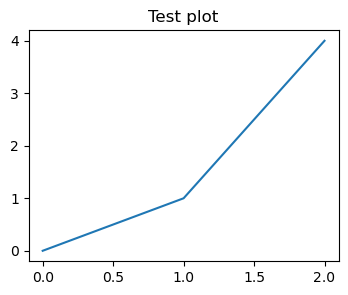

In [66]:
# Test matplotlib.pyplot availability and version
import matplotlib
import matplotlib.pyplot as plt
print('matplotlib version:', matplotlib.__version__)
print('backend:', matplotlib.get_backend())
fig = plt.figure(figsize=(4,3))
plt.plot([0,1,2],[0,1,4])
plt.title('Test plot')
plt.show()
plt.close(fig)

### 1. Loading Dataset into DataFrame

In [67]:
#df = pd.read_csv('online_retail.csv') # Use this for Colab
df = pd.read_csv('../data/bronze/online_retail.csv') #  Keep this for Git
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [68]:
df.shape

(541909, 9)

#### Inspecting Data Types

In [69]:
df.dtypes

index            int64
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

#### Summarizing Dataset

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


In [71]:
df.describe(include='all')

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.00000,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,NaN,25900,4070,4223,NaN,23260,NaN,NaN,38
top,NaN,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,NaN,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,270954.00000,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,156435.79785,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,0.00000,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,135477.00000,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,270954.00000,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,406431.00000,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


### 3. Fixing Data Types



1. `index`      : Keepting it as `int`
2. `InvoiceNo`  : Keeping it as `object`, since some invoices have the C letter at the begining (to define cancelled invoices)
3. `StockCode`  : Keeping it as `object`, as it contains letters in some cases
4. `Description`: Keeping it as `object` (String)
5. `Quantity`   : Keeping it as `int`
6. `InvoiceDate`: Changing it from `object` to `datetime`
7. `UnitPrice`  : Keeping it as `int`
8. `CustomerID` : Changing it from `float` to `int`
9. `Country`    : Keeping it as `object` (String)

#### CustomerID: Float to Int

In [72]:
#We confirmed first that there are no customerIDs with decimal values
#converting customerID to int from float


df['CustomerID'] = df['CustomerID'].astype('Int64')



#### InvoiceDate: Object to Datetime

In [73]:
#We confirmed first that there ae no InvoiceDate that in a non-datetime format

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


### 2. Removing Missing/Invalid Customer IDs

IMPORTANT NOTE:


Noticed ananymous transactions (No CustomerIDs) and decided to keep the orginal dataframe `df` as is, and create 2 other dataframes to export as csv and use as needed.
- The orginal dataframe `df` will allow us to perform transaction/sales-level analysis on all data (overall sales volume, average basket value, product-level demand, etc).
- The other two dataframes will allow us to split the data into:
    - `df_known_customers`: rows with a valid CustomerID. This dataset will serve to perform customer-level analysis (customer behavior, customer segmentation, customer retention, etc.)
    - `df_anonymous_transactions`: rows with missing CustomerID. If needed, this may help separately analyze anonymous transactions as a separate segment.

THIS WILL HAVE TO TAKE PLACE AFTER WE PERFORM OTHER DATA CLEANING TASKS. THERFORE, THE CORRESPONDING LINES OF CODE CAN BE FOUND IN SECTION 11.

Here, we will only replace missing customer IDs with "-1" to facilitate the analysis of `df` (using -1 to match the data type of int)

Some facts about the initial dataset:
- The number of unique invoices is: 25,900
- The number of unique customers is: 4372
- The number of invoices with more than one customer ID: 0
- The number of unique stock codes: 4070
- The number of rows with unknown customer IDs : 133,699
- The number of rows with known customer IDs : 148,817



In [74]:
#Replace missing Customer IDs with -1 and count the number of rows with known and unknown customer IDs
df['CustomerID'].fillna(-1, inplace=True)
print(f'The number of rows with unknown customer IDs : {len(df[df["CustomerID"] == -1])}')
print(f'The number of rows with known customer IDs : {len(df[df["CustomerID"] != -1])}')

The number of rows with unknown customer IDs : 135080
The number of rows with known customer IDs : 406829


C:\Users\Wassem\AppData\Local\Temp\ipykernel_23928\1105538516.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CustomerID'].fillna(-1, inplace=True)


In [75]:
df.describe(include='all')

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.00000,541909,541909,540455,541909.000000,541909,541909.000000,541909.0,541909
unique,NaN,25900,4070,4223,NaN,NaN,NaN,<NA>,38
top,NaN,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,<NA>,United Kingdom
freq,NaN,1114,2313,2369,NaN,NaN,NaN,<NA>,495478
mean,270954.00000,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,11476.725404,NaN
min,0.00000,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,-1.0,NaN
25%,135477.00000,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,12352.0,NaN
50%,270954.00000,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,14382.0,NaN
75%,406431.00000,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16255.0,NaN
max,541908.00000,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.0,NaN


### 7. Cancelled Invoices for Return Analysis

Cancelled items in invoices are important to the revenue analysis, since they represent a loss of revenue for the company.

Therefore, in task no 2, we will have to keep the cancelled invoices in the original `df` for our analysis and not drop them (eventhough they have negative Quantities).

This is why I brought this task befor the rest to use the `Cancelled` column in the following cleaning tasks.

NOTE: Will be exporting camcelled invoice to a separate csv for further analysis in section 11.




In [76]:
#Adding a column to indicate if an invoice is a cancelled one or not (Name: Cancelled, with boolean values)

df['Cancelled'] = df['InvoiceNo'].str.contains('C', na=False)


In [77]:
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False
1,1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False


### 4. Removing Negative or Zero Quantities

Identify negative quantities (that are not Cancelled Items):

- Number of rows with Quantity smaller than 0 that are not cancelled: 1336
- All of them have a unit price of 0.
- According to the desciptions, these are damaged, lost items, incorrect entries, etc. Which is why they have a negative quantity and a unit price of 0.
- These may be returns (not cancellations). We will export them to a separate `damages_returns_items` csv file for further analysis, then we will drop them from the main `df`.

Store damaged/returned items separately and removing them from `df`

In [78]:
# Create a separate dataframe for returns/damaged items
damages_returns_df = df[(df["Quantity"] < 0) & (df["Cancelled"] == 0)]

In [79]:
damages_returns_df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled
2406,2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,-1,United Kingdom,False
4347,4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,-1,United Kingdom,False
7188,7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,-1,United Kingdom,False
7189,7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,-1,United Kingdom,False
7190,7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,-1,United Kingdom,False


Save returns/damaged items separately

In [80]:
# Save damages_returns_df to a csv file
damages_returns_df.to_csv("../data/silver/damages_returns_items.csv", index=False)

Remove them from main df

In [81]:
# Drop them from the main df
df = df[~((df["Quantity"] < 0) & (df["Cancelled"] == 0))]
print(f'Number of rows after removing damaged items: {len(df)}')


Number of rows after removing damaged items: 540573


Confirming Removal

In [82]:
#No of items with negtive quantities that are not cancelled
print(f'Number of rows with Quantity smaller than 0 that are not cancelled: {len(df[(df["Quantity"] < 0) & (df["Cancelled"] == 0)])}')

Number of rows with Quantity smaller than 0 that are not cancelled: 0


Removing Negative Quantities from `df` (Cancelled items)

- Instead of deleating the cancelled items because of their negative quantities, we will convert them to positive
- However, it is important to ensure the revenue from these is negative when doing the analysis (Total price would have to be negative)

Coverting negative Quantities for cancelled items to positive Quantities

In [83]:
#Converting negative Quantities for cancelled items to positive Quantities
df.loc[(df["Quantity"] < 0) & (df["Cancelled"] == 1), "Quantity"] = -1 * df.loc[(df["Quantity"] < 0) & (df["Cancelled"] == 1), "Quantity"]

Verify cleaning (if there are any negative quantities left)

In [84]:
# Check minimum quantity after cleaning
df["Quantity"].min()

# Result = 1, so it seems we succeeded and there are no 0 Quantities in the df, so no need to remove them

1

### 5. Removing Duplicates

- To find duplicate rows, we looked looking in `df` without the index column (since indexes are all unique)
- Number of duplicate rows: 5268
- Assumption: if an invoice has two lines with the same StockCode, Description, Quantity, UnitPrice, CustomerID, Country and InvoiceDate, then we can consider them as duplicates.
- Action: we will keep the first occurrence of each duplicate row and drop the rest, ignoring the index column since it is not relevant


In [85]:
#Finding duplicate rows: looking in df without the index column (since indexes are all unique)
df2 = df.drop(columns=['index'])
duplicate_rows = df2[df2.duplicated()]

In [86]:
#Dropping duplicate rows
df = df.drop_duplicates(subset=['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'CustomerID', 'Country', 'InvoiceDate'], keep='first')
print(f'Number of rows after dropping duplicates: {len(df)}')

Number of rows after dropping duplicates: 535305


### 6. Cleaning StockCode & Description

Step 1 — Clean text formatting

In [87]:
# Clean text formatting
df["StockCode"] = df["StockCode"].astype(str).str.strip()

df["Description"] = df["Description"].astype(str).str.strip().str.upper()

Generate descriptions per StockCode



In [88]:
# Generate unique descriptions for each StockCode
stockcode_description_map = (
    df.groupby("StockCode")["Description"]
    .unique()
    .reset_index()
)

stockcode_description_map.head()

,StockCode,Description
0,10002,"[INFLATABLE POLITICAL GLOBE, NAN]"
1,10080,"[GROOVY CACTUS INFLATABLE, NAN, CHECK]"
2,10120,[DOGGY RUBBER]
3,10123C,[HEARTS WRAPPING TAPE]
4,10124A,[SPOTS ON RED BOOKCOVER TAPE]


Find StockCodes with multiple descriptions

In [89]:
# Find StockCodes with multiple descriptions
multiple_description_stockcodes = stockcode_description_map[
    stockcode_description_map["Description"].apply(len) > 1
]

multiple_description_stockcodes.head(20)

,StockCode,Description
0,10002,"[INFLATABLE POLITICAL GLOBE, NAN]"
1,10080,"[GROOVY CACTUS INFLATABLE, NAN, CHECK]"
10,15030,"[FAN BLACK FRAME, NAN]"
24,15058A,"[BLUE POLKADOT GARDEN PARASOL, NAN]"
27,15060B,"[FAIRY CAKE DESIGN UMBRELLA, NAN]"
34,16015,"[MEDIUM CHINESE STYLE SCISSOR, NAN]"
37,16033,"[MINI HIGHLIGHTER PENS, NAN]"
40,16046,"[TEATIME PEN CASE & PENS, NAN]"
42,16049,"[TEATIME GEL PENS ASST, NAN]"
46,16156L,"[WRAP, CAROUSEL, WRAP CAROUSEL]"


Preserve missing descriptions

In [90]:
# View missing descriptions
missing_description_df = df[
    df["Description"].isnull() |
    (df["Description"] == "NAN")
]

missing_description_df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled
622,622,536414,22139,NAN,56,2010-12-01 11:52:00,0.0,-1,United Kingdom,False
1970,1970,536545,21134,NAN,1,2010-12-01 14:32:00,0.0,-1,United Kingdom,False
1971,1971,536546,22145,NAN,1,2010-12-01 14:33:00,0.0,-1,United Kingdom,False
1972,1972,536547,37509,NAN,1,2010-12-01 14:33:00,0.0,-1,United Kingdom,False
1987,1987,536549,85226A,NAN,1,2010-12-01 14:34:00,0.0,-1,United Kingdom,False


Save inconsistent descriptions separately

In [91]:
# Save inconsistent StockCode descriptions
multiple_description_stockcodes.to_csv(
    "../data/silver/stockcode_description_issues.csv",
    index=False
)

In [92]:
# I think we chould add a code to replace NAN description for each Stock code with the longest description available for that stock code - Souhaila
'''for stock_code in multiple_description_stockcodes['StockCode']:
    descriptions = stockcode_description_map[stockcode_description_map['StockCode'] == stock_code]['Description'].iloc[0]
    longest_description = max(descriptions, key=len)
    df.loc[df['StockCode'] == stock_code, 'Description'] = longest_description

df.groupby("StockCode")["Description"].head()'''

for stock_code in multiple_description_stockcodes['StockCode']:
    # Get all descriptions for this stock code
    descriptions = (
        stockcode_description_map
        .loc[stockcode_description_map['StockCode'] == stock_code, 'Description']
        .iloc[0]  # Get the array of descriptions for this stock code
    )
    # Find the longest description
    longest_description = max(descriptions, key=len)
    # Replace all descriptions for this stock code with the longest one
    df.loc[df['StockCode'] == stock_code, 'Description'] = longest_description

df.groupby("StockCode")["Description"].head()


0          WHITE HANGING HEART T-LIGHT HOLDER
1                WHITE MOROCCAN METAL LANTERN
2              CREAM CUPID HEARTS COAT HANGER
3         KNITTED UNION FLAG HOT WATER BOTTLE
4              RED WOOLLY HOTTIE WHITE HEART.
                         ...                 
540511    SET 10 CARDS CHRISTMAS HOLLY  17259
540512      SET 10 CARDS CHRISTMAS TREE 16955
540861           CRACKED GLAZE EARRINGS BROWN
540874    IVORY PENDANT TRIPLE SHELL NECKLACE
541525           3D DOG PICTURE PLAYING CARDS
Name: Description, Length: 18506, dtype: object

In [93]:
#were we succssful, find descriptions in df with NAN values, group by stock code
stockcode_description_map = (
    df.groupby("StockCode")["Description"]
    .unique()
    .reset_index()
)
stockcode_description_map.head()
#YES, we were successful, there are no more NAN descriptions for any stock code, and each stock code has only one unique description now.

,StockCode,Description
0,10002,[INFLATABLE POLITICAL GLOBE]
1,10080,[GROOVY CACTUS INFLATABLE]
2,10120,[DOGGY RUBBER]
3,10123C,[HEARTS WRAPPING TAPE]
4,10124A,[SPOTS ON RED BOOKCOVER TAPE]


Create description categories

In [94]:
# Souhaila - find most occuring words in the descriptions, exclude colors, prepositions, conjunctions, numbers, etc. (e.g. 'OF', 'AND', 'THE', etc.) since they are not relevant for our analysis and can skew the results.

from collections import Counter

colors = ['RED', 'BLUE', 'GREEN', 'YELLOW', 'BLACK', 'WHITE', 'PINK', 'PURPLE', 'ORANGE', 'BROWN', 'GREY']
stop_words = ['OF', 'AND', 'THE', 'IN', 'ON', 'AT', 'BY', 'FOR', 'WITH', 'TO', 'FROM', 'AS', 'IS', 'ARE', 'WAS', 'WERE', 'BE', 'BEEN', 'HAS', 'HAVE', 'DO', 'DID', 'A', 'AND', 'BUT', 'OR', 'NOR', 'SO', 'YET', 'IF', 'THEN', 'ELSE', 'WHEN', 'WHILE', 'WHERE', 'HOW', 'ALL', 'ANY', 'SOME', 'NO', 'NOT', 'ONLY', 'VERY', 'JUST', 'OVER', 'UNDER', 'ABOVE', 'BELOW', 'UP', 'DOWN', 'OUT', 'INTO', 'ONTO', 'OFF', 'ABOUT', 'AGAINST', 'BETWEEN', 'AMONG', 'THROUGH', 'DURING', 'WITHOUT', 'WITHIN', 'BEYOND', 'NEAR', 'FAR', 'BEFORE', 'AFTER', 'SINCE', 'UNTIL', 'WHOM', 'WHO', 'WHICH', 'THAT', 'THIS', 'THESE', 'THOSE', 'MY', 'YOUR', 'HIS', 'HER', 'ITS', 'OUR', 'THEIR', 'ME', 'YOU', 'HIM', 'HER', 'IT', 'US', 'THEM']
sizes = ['SMALL', 'MEDIUM', 'LARGE', 'EXTRA LARGE', 'S', 'M', 'L', 'XL', 'XXL']
styles = ['VINTAGE', 'MODERN', 'CLASSIC', 'CASUAL', 'FORMAL', 'SPORTY', 'ELEGANT', 'FASHIONABLE', 'TRENDY', 'CHIC']
motifs = ['FLORAL', 'STRIPED', 'POLKADOT', 'CHECKERED', 'ANIMAL PRINT', 'GEOMETRIC', 'PLAID', 'CAMOUFLAGE', 'TIE-DYE', 'SOLID', 'RETROSPOT']
matrials = ['COTTON', 'POLYESTER', 'WOOL', 'SILK', 'LEATHER', 'DENIM', 'LACE', 'FUR', 'SUEDE', 'NYLON', 'METAL', 'PLASTIC', 'GLASS', 'WOODEN', 'CERAMIC', 'PAPER', 'CARD' 'RUBBER', 'FOAM', 'FIBERGLASS', 'CARDBOARD']
numbers = [str(i) for i in range(100)]


all_descriptions = ' '.join(df['Description'].dropna()).split()
word_counts = Counter(all_descriptions)
#exluding colors, stop words and numbers from the word counts
for word in list(word_counts.keys()):
    if word in colors or word in stop_words or word in numbers or word in sizes or word in styles or word in motifs or word in matrials:
        del word_counts[word]
most_common_words = word_counts.most_common(30)
print("Most common words in descriptions:")
for word, count in most_common_words:
    print(f"{word}: {count}")


Most common words in descriptions:
SET: 55824
BAG: 50897
HEART: 38362
DESIGN: 29895
CHRISTMAS: 25066
BOX: 24201
CAKE: 21045
JUMBO: 20329
LUNCH: 18294
SIGN: 16906
HANGING: 16857
HOLDER: 16209
PACK: 15516
T-LIGHT: 14158
CARD: 13079
DECORATION: 12952
TEA: 12086
CASES: 11821
BOTTLE: 11589
SPACEBOY: 10505
HOT: 10409
WATER: 9868
PANTRY: 9714
HOME: 9451
TIN: 9414
ROSE: 9347
PAISLEY: 9233
REGENCY: 9041
DOORMAT: 8359
DOLLY: 8343


In [95]:
# Product category segmentation
def categorize_product(description):
    if "HEART" in str(description) or "SET" in str(description) or "DECORATION" in str(description) or "CHRISTMAS" in str(description):
        category = "Decor"

    elif "LANTERN" in str(description):
        category = "Lighting"

    elif "CAKE" in str(description) or "LUNCH" in str(description) or "TEA" in str(description) or "BOTTLE" in str(description):
        category = "Kitchen"

    elif "BAG" in str(description):
        category = "Accessories"

    elif "CHALK" in str(description):
        category = "Office"

    elif "HOME" in str(description) or "DOORMAT" in str(description) or "HANGER" in str(description):
        category = "Home"

    elif str(description) == "NAN":
        category = "Missing"

    else:
        category = "Other"

    return category

#loop over all descriptions and assign a category to each description based on the keywords in the description
prdCatList =[]
for descrip in df["Description"]:
    productCategory = categorize_product(descrip)
    prdCatList.append(productCategory)

df["ProductCategory"] = prdCatList

df.head(10)

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled,ProductCategory
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,Decor
1,1,536365,71053,WHITE MOROCCAN METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Lighting
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,Decor
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Kitchen
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Decor
5,5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,False,Decor
6,6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,False,Other
7,7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,False,Other
8,8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,False,Other
9,9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,False,Other


### 8. Creating Total Price Column

*   Decided to keep all total prices as positive (even for cancelled items)
*   !NOTE: make sure to negate them when calculating total revenue



In [96]:
#creating Total price column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()


,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled,ProductCategory,TotalPrice
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,Decor,15.30
1,1,536365,71053,WHITE MOROCCAN METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Lighting,20.34
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,Decor,22.00
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Kitchen,20.34
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Decor,20.34


In [97]:
df['TotalPrice'].min() # min is -11062.06 due to negative unit prices, we will handle those in outliers cleaning step

-11062.06

### 9. Outlier Detection

In [98]:
#Defining Plot Function for a column distribution
def plot_column_distribution(dataframe, column, binSize,rMin, rMax, fliers):
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.hist(dataframe[column], bins=binSize, edgecolor='k', range=(rMin, rMax))
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.subplot(1, 2, 2)
    plt.boxplot(dataframe[column], vert=False, showfliers=fliers)
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

#### Quantity Column

Handling rows that have a 'Quantity' value smaller than 0, which are not cancelled invoices

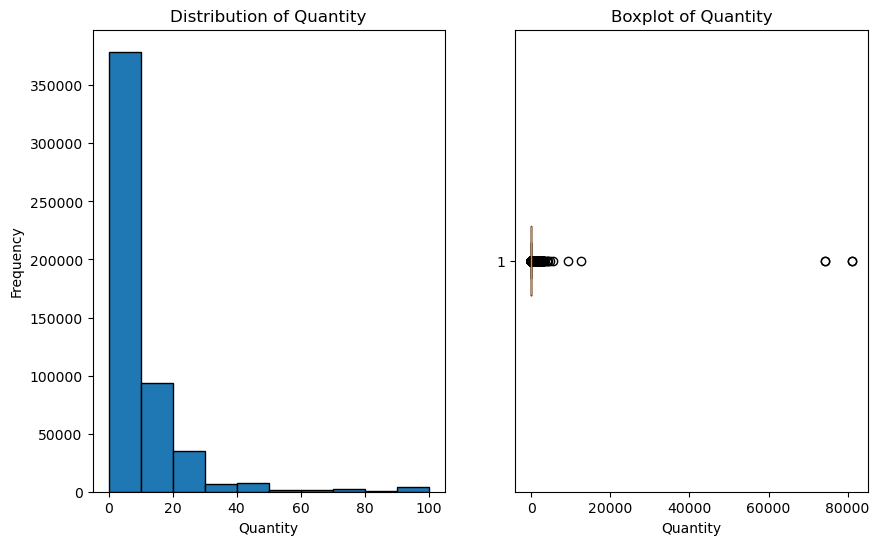

Mean of Quantity: 11.060197457524215
Median of Quantity: 3.0


In [99]:
#Now, lets see the distribution of the 'Quantity' column to decide how to handle the outliers
plot_column_distribution(df,'Quantity', 10, 0, 100, True)
#calculate the mean and median of the 'Quantity' column in the updated df
print(f'Mean of Quantity: {df["Quantity"].mean()}')
print(f'Median of Quantity: {df["Quantity"].median()}')

Outliers in the 'Quantity' column using the IQR method

In [100]:
#Detecting Outliers in the 'Quantity' column using the IQR method

#NOTE: We are not using the Z-score method to handle outliers in the 'Quantity' column since it is not suitable for right-skewed distributions with a long tail, as is the case with our 'Quantity' column.
# since the Quantity column is right-skewed, we will have a lot of outliers using the IQR method
# to handle outliers in the 'Quantity' column, since it is more suitable for right-skewed distributions with a long tail.

Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
print(f'Q1: {Q1}, Q3: {Q3}')
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Lower bound: {lower_bound}, Upper bound: {upper_bound}')
outliers = df[(df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)]
print(f'Number of outliers in the Quantity column using IQR method: {len(outliers)}')

Q1: 1.0, Q3: 11.0
Lower bound: -14.0, Upper bound: 26.0
Number of outliers in the Quantity column using IQR method: 27910


99th percentile value of Quantity: 100.0


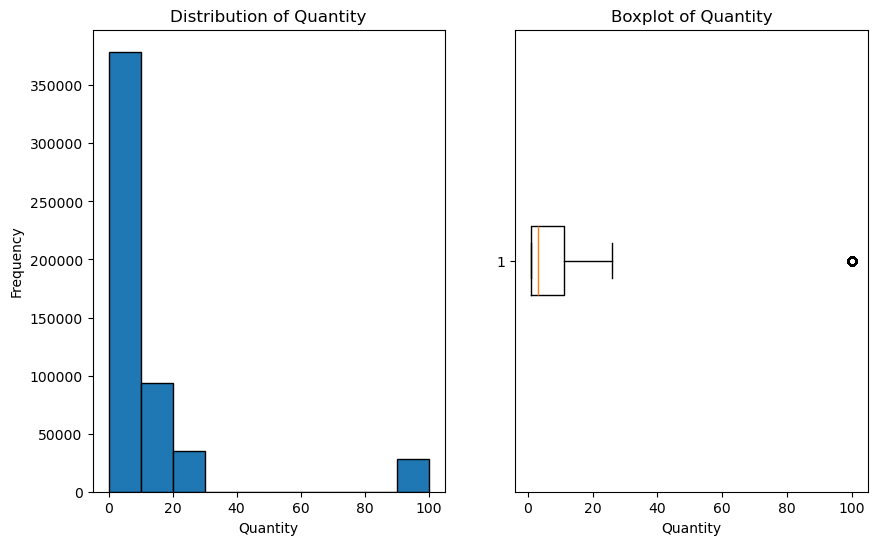

In [101]:
# Action: we will replace the outliers by setting values above the 99th percentile to the 99th percentile value

p99_quantity = df['Quantity'].quantile(0.99)
print(f'99th percentile value of Quantity: {p99_quantity}')

df['Quantity'] = np.where((df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound) , p99_quantity, df['Quantity'])

#plotting the distribution of the 'Quantity' column after handling outliers
plot_column_distribution(df,'Quantity', 10, 0, 100, True)




#### Unit Price Column

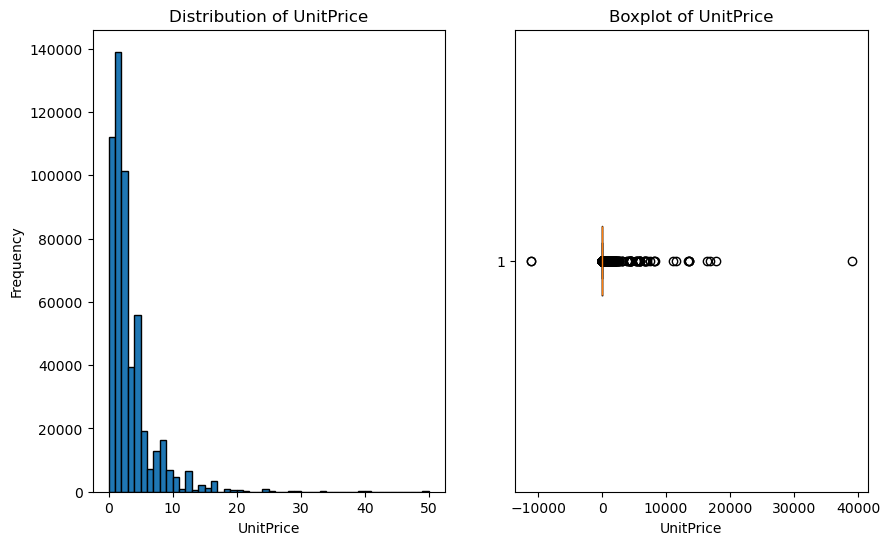

In [102]:
# plotting the distribution
plot_column_distribution(df,'UnitPrice', 50, 0, 50, True)

Removing Negative UnitPrices and putting them in a separate csv file

In [103]:
#let's obseve entries that have negative unit price values to confirm that they are indeed outliers and not valid entries that we should keep for our analysis (e.g. returns, discounts, etc.)
#print(df[df['UnitPrice'] < 0].head())

#let's find the description of the entries that have negative unit price values to see if they are indeed outliers and not valid entries that we should keep for our analysis (e.g. returns, discounts, etc.)
#print(df[df['UnitPrice'] < 0]['Description'].unique())
#Result:['Adjust bad debt']

#Seems like all the entries with negative unit price values are related to bad debt adjustments,
#which are not valid entries that we should keep for our analysis, since they do not represent actual sales transactions and can skew our revenue analysis.
# We can safley exclude these entries from the dataframe
# (we can keep them in a separate dataframe for further analysis if needed)

#Creating a new dataframe for bad debt adjustments
df_bad_debt_adjustments = df[df['UnitPrice'] < 0]
print(f'Number of bad debt adjustments (UnitPrice < 0): {len(df_bad_debt_adjustments)}')



Number of bad debt adjustments (UnitPrice < 0): 2


In [104]:
#exporting the bad debt adjustments to a new csv file and putting it in the silver layer for further analysis
df_bad_debt_adjustments.to_csv('../data/silver/bad_debt_adjustments.csv', index=False)

In [105]:
#Updating the original dataframe by removing the bad debt adjustments (in case Danny did not remove them in the previous steps)
df = df[df['UnitPrice'] >= 0]
print(f'Number of rows after removing bad debt adjustments: {len(df)}')

Number of rows after removing bad debt adjustments: 535303


In [106]:
# are there any unit prices = 0


df_null_prices = df[df['UnitPrice'] == 0]
print(f'Number of null prices (UnitPrice == 0): {len(df_null_prices)}')

Number of null prices (UnitPrice == 0): 1174


In [107]:
# how to hundle null prices (UnitPrice == 0)?
# let's look at stockcodes and see what are thir associated unit prices (if there ae many)
stockcode_unitprice_map = (
    df.groupby("StockCode")["UnitPrice"]
    .unique()
    .reset_index()
)
stockcode_unitprice_map.head()

,StockCode,UnitPrice
0,10002,"[0.85, 1.66, 1.63, 0.0]"
1,10080,"[0.85, 0.39, 0.0]"
2,10120,[0.21]
3,10123C,[0.65]
4,10124A,[0.42]


Handling Unit Prices that are equal to 0
- if one stock code has many unit prices : replase the 0 value with the median
- if a stock code has obly one unit price, and that unitPrice is equal to 0, we will remove those entries from the dataframe (they are 25 entries)

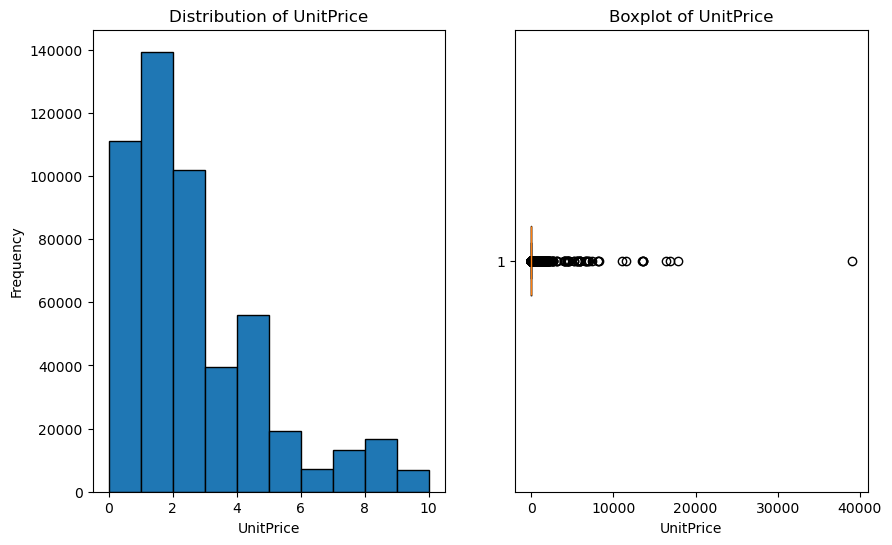

In [108]:
#let's replace the null prices (UnitPrice == 0) with the median unit price for each StockCode, since it is more robust to outliers than the mean and can give us a better estimate of the typical unit price for each StockCode.
for stock_code in df_null_prices['StockCode'].unique():
    median_unit_price = df[df['StockCode'] == stock_code]['UnitPrice'].median()
    df.loc[(df['StockCode'] == stock_code) & (df['UnitPrice'] == 0), 'UnitPrice'] = median_unit_price

#observing the distribution of the 'UnitPrice' column after handling null prices
plot_column_distribution(df,'UnitPrice', 10, 0, 10, True)


In [109]:
# any prices ==0 left?
len (df[df['UnitPrice'] == 0])
# YES : 25
# We will drop them from the Dataframe
df.drop(df[df['UnitPrice'] == 0].index, inplace=True)
len (df[df['UnitPrice'] == 0])

0

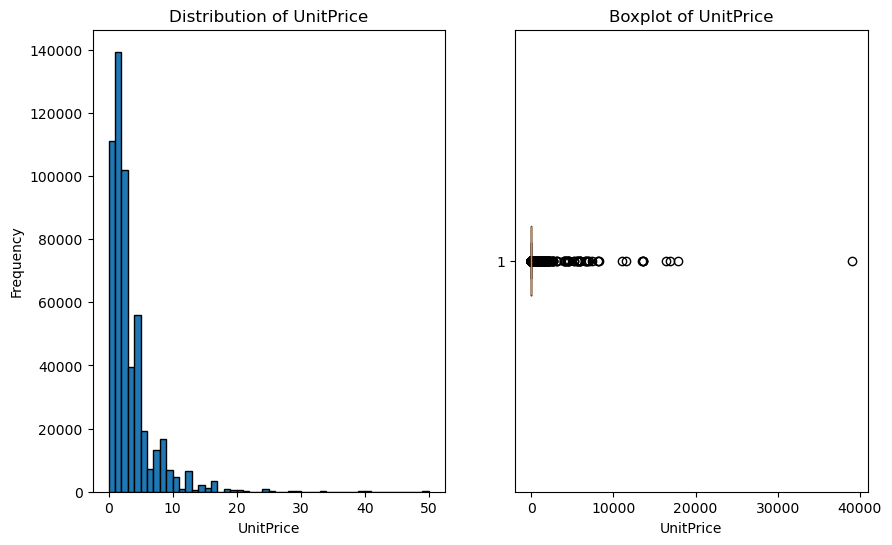

In [110]:
#observing the distribution of the 'UnitPrice' column after removing bad debt adjustments
plot_column_distribution(df,'UnitPrice', 50, 0, 50, True)

Outliers in the 'UnitPrice' column using the IQR method

In [111]:
#Detecting Outliers in the 'UnitPrice' column using the IQR method
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
print(f'Q1: {Q1}, Q3: {Q3}')

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Lower bound: {lower_bound}, Upper bound: {upper_bound}')

outliers_unit_price = df[(df['UnitPrice'] < lower_bound) | (df['UnitPrice'] > upper_bound)]
print(f'Number of outliers in the UnitPrice column using IQR method: {len(outliers_unit_price)}')



Q1: 1.25, Q3: 4.13
Lower bound: -3.0700000000000003, Upper bound: 8.45
Number of outliers in the UnitPrice column using IQR method: 39552


In [112]:
# Action: we can replace the outliers  by setting values above the 99th percentile to the 99th percentile value

unit_price_99th_percentile = df['UnitPrice'].quantile(0.99)
# Result:unit_price_99th_percentile = 18.0
df['UnitPrice'] = np.where(df['UnitPrice'] > unit_price_99th_percentile, unit_price_99th_percentile, df['UnitPrice'])

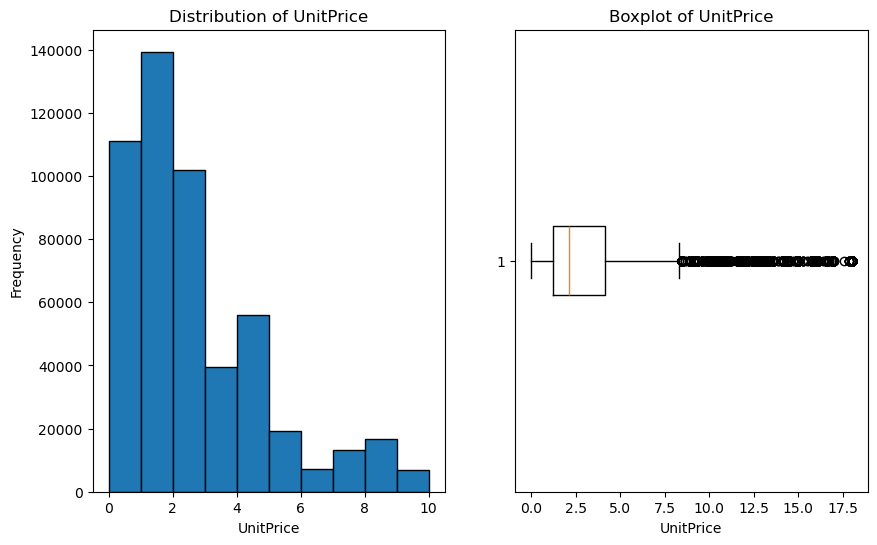

In [113]:
#observing the distribution of the 'UnitPrice' column after handling outliers
plot_column_distribution(df,'UnitPrice', 10, 0, 10, True)

### 10. Feature Engineering

10.) Feature Engineering



Extract Year

In [114]:
df["Year"] = df["InvoiceDate"].dt.year

Extract Month

In [115]:
df["Month"] = df["InvoiceDate"].dt.month

Extract Day

In [116]:
df["Day"] = df["InvoiceDate"].dt.day

Extract Hour

In [117]:
df["Hour"] = df["InvoiceDate"].dt.hour

Create Weekend Column

In [118]:
df["Weekend"] = df["InvoiceDate"].dt.dayofweek >= 5

Customer Spending Category

In [119]:
labels=['Low','Medium','High']
bins=[0, 10, 100, float('inf')]
df['ExpenseCategory'] = pd.cut(df['TotalPrice'], bins=bins, labels=labels, include_lowest=False)

print(df['ExpenseCategory'].value_counts())

ExpenseCategory
Low       273583
Medium    246424
High       14122
Name: count, dtype: int64


In [120]:
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled,ProductCategory,TotalPrice,Year,Month,Day,Hour,Weekend,ExpenseCategory
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,Decor,15.30,2010,12,1,8,False,Medium
1,1,536365,71053,WHITE MOROCCAN METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Lighting,20.34,2010,12,1,8,False,Medium
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,Decor,22.00,2010,12,1,8,False,Medium
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Kitchen,20.34,2010,12,1,8,False,Medium
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Decor,20.34,2010,12,1,8,False,Medium


### 11. Export the clean dataset in "Silver” Folder

In [121]:
#dropping the index column from the dataset
df = df.drop(columns=['index'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled,ProductCategory,TotalPrice,Year,Month,Day,Hour,Weekend,ExpenseCategory
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,Decor,15.30,2010,12,1,8,False,Medium
1,536365,71053,WHITE MOROCCAN METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Lighting,20.34,2010,12,1,8,False,Medium
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,Decor,22.00,2010,12,1,8,False,Medium
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Kitchen,20.34,2010,12,1,8,False,Medium
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Decor,20.34,2010,12,1,8,False,Medium


In [122]:
#Exporting the clean dataset in "Silver" Folder
#df.to_csv('online_retail_cleaned.csv', index=False) #Use this for Colab
df.to_csv('../data/silver/online_retail_cleaned.csv', index=False) #Keep for Git

In [123]:
df_known_customers = df[df['CustomerID'] != -1]
print(f'The number of transactions with known customers is: {len(df_known_customers)}')
df_known_customers.info()

The number of transactions with known customers is: 401604
<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   InvoiceNo        401604 non-null  object        
 1   StockCode        401604 non-null  object        
 2   Description      401604 non-null  object        
 3   Quantity         401604 non-null  float64       
 4   InvoiceDate      401604 non-null  datetime64[ns]
 5   UnitPrice        401604 non-null  float64       
 6   CustomerID       401604 non-null  Int64         
 7   Country          401604 non-null  object        
 8   Cancelled        401604 non-null  bool          
 9   ProductCategory  401604 non-null  object        
 10  TotalPrice       401604 non-null  float64       
 11  Year             401604 non-null  int32         
 12  Month            401604 non-null  int32         
 13  Day              401

In [124]:
#exporting df_known_customers to a new csv file and putting it in the silver layer for further analysis
df_known_customers.to_csv('../data/silver/known_customers.csv', index=False)

In [125]:
df_anonymous_transactions = df[df['CustomerID'] == -1]
print(f'The number of transactions with unknown customers is: {len(df_anonymous_transactions)}')
df_anonymous_transactions.info()


The number of transactions with unknown customers is: 133674
<class 'pandas.core.frame.DataFrame'>
Index: 133674 entries, 622 to 541540
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   InvoiceNo        133674 non-null  object        
 1   StockCode        133674 non-null  object        
 2   Description      133674 non-null  object        
 3   Quantity         133674 non-null  float64       
 4   InvoiceDate      133674 non-null  datetime64[ns]
 5   UnitPrice        133674 non-null  float64       
 6   CustomerID       133674 non-null  Int64         
 7   Country          133674 non-null  object        
 8   Cancelled        133674 non-null  bool          
 9   ProductCategory  133674 non-null  object        
 10  TotalPrice       133674 non-null  float64       
 11  Year             133674 non-null  int32         
 12  Month            133674 non-null  int32         
 13  Day             

In [126]:
df_anonymous_transactions.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled,ProductCategory,TotalPrice,Year,Month,Day,Hour,Weekend,ExpenseCategory
count,133674,133674,133674,133674.000000,133674,133674.000000,133674.0,133674,133674,133674,133674.000000,133674.000000,133674.000000,133674.000000,133674.000000,133674,132565
unique,2348,3524,3400,NaN,NaN,NaN,<NA>,9,2,7,NaN,NaN,NaN,NaN,NaN,2,3
top,573585,DOT,DOTCOM POSTAGE,NaN,NaN,NaN,<NA>,United Kingdom,False,Other,NaN,NaN,NaN,NaN,NaN,False,Low
freq,1114,694,694,NaN,NaN,NaN,<NA>,132209,133295,72497,NaN,NaN,NaN,NaN,NaN,132541,97276
mean,NaN,NaN,NaN,3.746667,2011-06-16 03:54:14.279814656,4.425621,-1.0,NaN,NaN,NaN,15.262446,2010.883755,7.401566,14.981507,14.112041,NaN,NaN
min,NaN,NaN,NaN,1.000000,2010-12-01 11:52:00,0.060000,-1.0,NaN,NaN,NaN,0.000000,2010.000000,1.000000,1.000000,8.000000,NaN,NaN
25%,NaN,NaN,NaN,1.000000,2011-02-21 08:33:00,1.630000,-1.0,NaN,NaN,NaN,2.500000,2011.000000,4.000000,8.000000,12.000000,NaN,NaN
50%,NaN,NaN,NaN,1.000000,2011-06-28 11:45:00,3.290000,-1.0,NaN,NaN,NaN,4.960000,2011.000000,8.000000,14.000000,15.000000,NaN,NaN
75%,NaN,NaN,NaN,3.000000,2011-10-12 14:05:00,5.790000,-1.0,NaN,NaN,NaN,10.790000,2011.000000,11.000000,22.000000,16.000000,NaN,NaN
max,NaN,NaN,NaN,100.000000,2011-12-09 10:26:00,18.000000,-1.0,NaN,NaN,NaN,17836.460000,2011.000000,12.000000,31.000000,19.000000,NaN,NaN


In [127]:
#exporting df_anonymous_transactions to a new csv file and putting it in the silver layer for further analysis
df_anonymous_transactions.to_csv('../data/silver/anonymous_transactions.csv', index=False)

In [128]:
# Creating a new dataframe for cancelled invoices (assuming that cancelled invoices are those with a C in the 'InvoiceNo' column)
df_cancelled_invoices = df[df["Cancelled"] == 1]
print(f'Number of cancelled invoices: {len(df_cancelled_invoices)}')
#df_cancelled_invoices.head()

#exporting the cancelled invoices to a new csv file and putting it in the silver layer for further analysis
df_cancelled_invoices.to_csv('../data/silver/cancelled_invoices.csv', index=False)

#NOTE: We might want to execute this cell after we finish cleaning the data,
#since we might want to update the cancelled invoices dataframe with the cleaned data (no nulls, outliers, etc.).


Number of cancelled invoices: 9251
